<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day3_Exercises_XP_GOLD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Distribution Univariée ===
Moyenne empirique : 0.019
Écart-type empirique : 0.979

=== Distribution Multivariée (indépendante) ===
Moyennes empiriques : [0.02627068 0.05039977]
Matrice de covariance empirique :
[[0.94126868 0.03709456]
 [0.03709456 1.02265223]]

=== Distribution Multivariée (corrélée) ===
Matrice de covariance empirique :
[[1.01807226 0.80518082]
 [0.80518082 1.0047163 ]]


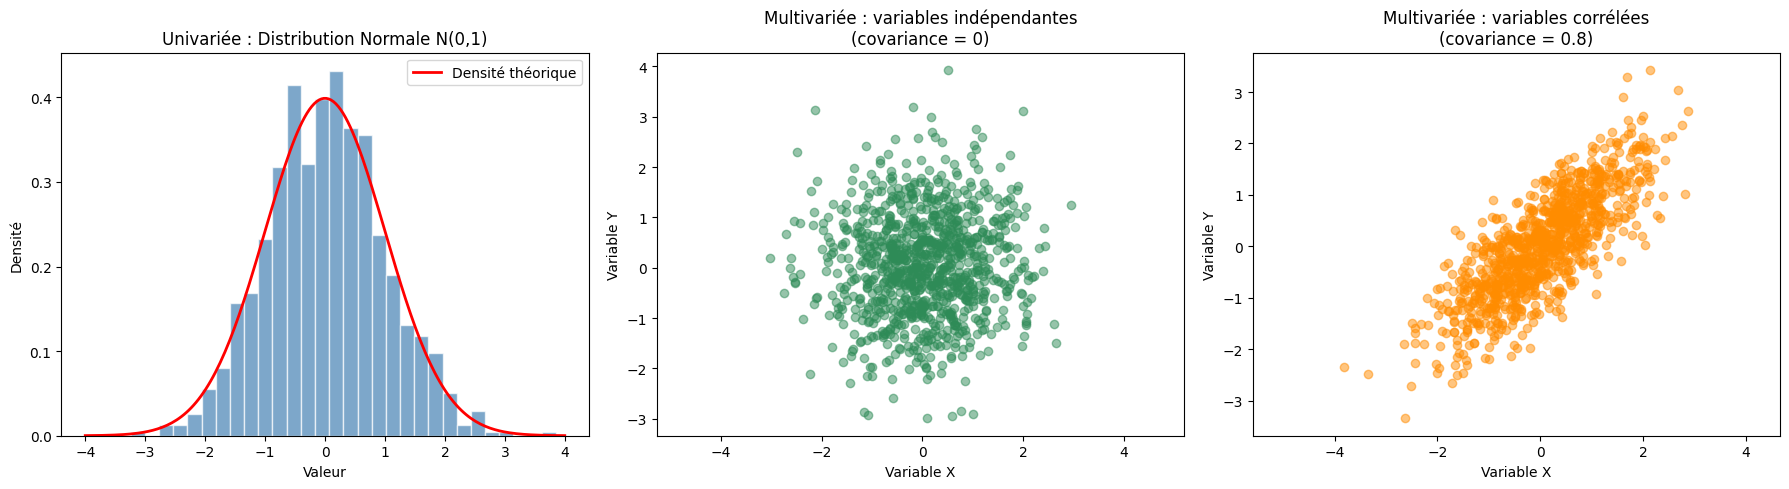

In [2]:
# ============================================================
# EXERCICE 1 : Distribution Normale Univariée vs Multivariée
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# Reproductibilité : fixe la graine aléatoire pour que tout le monde
# obtienne les mêmes résultats en relançant le code
np.random.seed(42)

# ------------------------------------------------------------
# 1) DISTRIBUTION UNIVARIÉE
# ------------------------------------------------------------
# norm.rvs() génère des échantillons aléatoires suivant une loi normale
# par défaut : moyenne (loc) = 0, écart-type (scale) = 1 -> loi normale "standard"
univariate_data = norm.rvs(loc=0, scale=1, size=1000)

print("=== Distribution Univariée ===")
print(f"Moyenne empirique : {univariate_data.mean():.3f}")
print(f"Écart-type empirique : {univariate_data.std():.3f}")
# -> On s'attend à des valeurs proches de 0 et 1 (la loi théorique),
#    mais pas exactement, car on a un échantillon fini (1000 points)

# ------------------------------------------------------------
# 2) DISTRIBUTION MULTIVARIÉE (2 dimensions)
# ------------------------------------------------------------
mean = [0, 0]            # moyenne de chaque variable (X et Y)
cov_independent = [[1, 0],
                    [0, 1]]  # matrice de covariance DIAGONALE
                              # -> variance de X = 1, variance de Y = 1
                              # -> covariance(X,Y) = 0 -> variables indépendantes

multivariate_data_indep = multivariate_normal.rvs(
    mean=mean, cov=cov_independent, size=1000
)

# On crée une 2ème version AVEC corrélation pour bien voir la différence
cov_correlated = [[1, 0.8],
                   [0.8, 1]]  # covariance = 0.8 -> X et Y évoluent ensemble

multivariate_data_corr = multivariate_normal.rvs(
    mean=mean, cov=cov_correlated, size=1000
)

print("\n=== Distribution Multivariée (indépendante) ===")
print(f"Moyennes empiriques : {multivariate_data_indep.mean(axis=0)}")
print(f"Matrice de covariance empirique :\n{np.cov(multivariate_data_indep.T)}")

print("\n=== Distribution Multivariée (corrélée) ===")
print(f"Matrice de covariance empirique :\n{np.cov(multivariate_data_corr.T)}")

# ------------------------------------------------------------
# 3) VISUALISATION COMPARATIVE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : histogramme de la loi univariée
axes[0].hist(univariate_data, bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white')
x_vals = np.linspace(-4, 4, 200)
axes[0].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r-', linewidth=2, label='Densité théorique')
axes[0].set_title("Univariée : Distribution Normale N(0,1)")
axes[0].set_xlabel("Valeur")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Graphique 2 : nuage de points 2D - variables INDÉPENDANTES
axes[1].scatter(multivariate_data_indep[:, 0], multivariate_data_indep[:, 1],
                alpha=0.5, color='seagreen')
axes[1].set_title("Multivariée : variables indépendantes\n(covariance = 0)")
axes[1].set_xlabel("Variable X")
axes[1].set_ylabel("Variable Y")
axes[1].axis('equal')  # même échelle sur les 2 axes -> on voit la vraie forme du nuage

# Graphique 3 : nuage de points 2D - variables CORRÉLÉES
axes[2].scatter(multivariate_data_corr[:, 0], multivariate_data_corr[:, 1],
                alpha=0.5, color='darkorange')
axes[2].set_title("Multivariée : variables corrélées\n(covariance = 0.8)")
axes[2].set_xlabel("Variable X")
axes[2].set_ylabel("Variable Y")
axes[2].axis('equal')

plt.tight_layout()
plt.show()

***Distribution de Poisson***

Scénario : nombre de clients arrivant dans un magasin pendant un intervalle de temps fixe (ex: 1 heure).
Pourquoi Poisson et pas Normale ?

On compte des événements discrets (0, 1, 2, 3... clients — jamais 2.5 clients)
Les événements sont rares et indépendants : l'arrivée d'un client n'influence pas directement l'arrivée du suivant
Il y a un seul paramètre : λ (lambda), qui représente à la fois la moyenne et la variance du nombre d'événements sur l'intervalle

Hypothèses  :

Les arrivées sont indépendantes les unes des autres
Le taux moyen λ est constant dans le temps (pas de pic d'affluence à midi vs le soir — sinon le modèle simple ne tient plus)
Deux événements ne peuvent pas arriver exactement au même instant

Implication pratique : si λ = 5 (5 clients/heure en moyenne), Poisson permet de calculer la probabilité d'avoir exactement 0, 1, 10... clients dans l'heure. C'est utilisé en gestion des stocks, dimensionnement du personnel, centres d'appels, etc.
💡 Tip : si tu observais que la variance du nombre de clients est beaucoup plus grande que la moyenne (sur-dispersion), Poisson serait un mauvais choix — on utiliserait plutôt une loi binomiale négative. C'est le genre de vérification qu'on fait avant de valider un modèle.



**Distribution Exponentielle**

Scénario : temps écoulé jusqu'au prochain tremblement de terre dans une région à risque sismique.
Pourquoi Exponentielle ?

On modélise un temps d'attente continu entre deux événements (pas un comptage)
Elle a une propriété unique : l'absence de mémoire ("memoryless property") — la probabilité d'attendre encore X minutes ne dépend pas du temps déjà écoulé. Si tu as attendu 10 ans sans séisme, la probabilité d'attendre encore 1 an est la même que si tu venais juste de commencer à observer.
Un seul paramètre : λ, le taux d'occurrence (le même λ que pour Poisson !)

Le lien avec Poisson 🔗 : si le nombre d'événements (séismes) dans un intervalle de temps suit une loi de Poisson(λ), alors le temps entre deux événements suit une loi Exponentielle(λ). C'est la même réalité physique vue sous deux angles : comptage vs temps d'attente.
Hypothèses :

Les séismes sont des événements indépendants (hypothèse discutable en réalité — un séisme peut déclencher des répliques, donc l'indépendance n'est qu'une approximation)
Le taux λ est constant dans le temps (pas de saisonnalité)

Implication pratique : permet d'estimer la probabilité qu'aucun séisme ne survienne dans les 5 prochaines années, ou le temps moyen d'attente — utile pour la gestion du risque, l'assurance, la planification d'infrastructures.
💡 Tip : en pratique, la propriété d'absence de mémoire est souvent violée dans des phénomènes naturels complexes (les séismes ont tendance à arriver en grappes/répliques). C'est pour ça qu'en sismologie réelle on utilise des modèles plus sophistiqués (processus de Hawkes). Mentionner cette limite dans ta réponse montre que tu comprends les limites du modèle, pas juste la formule — c'est ce qui distingue une bonne réponse d'une excellente.

=== Statistiques descriptives par région ===
           Region 1      Region 2      Region 3
count     30.000000     30.000000     30.000000
mean   21328.569342  20986.673503  24331.395024
std     3300.985250   3199.834780   4825.219363
min    12341.030552  15067.212361  16368.586988
25%    19582.032142  18872.587748  20718.077838
50%    21216.133565  20756.356698  23771.306580
75%    24006.168879  22930.794080  27324.711968
max    26809.263872  28827.713883  34479.445880

F-statistic : 6.8624
p-value     : 0.0017

p-value (0.0017) < alpha (0.05) -> on REJETTE H0
Conclusion : au moins une région a une moyenne de ventes significativement différente des autres.


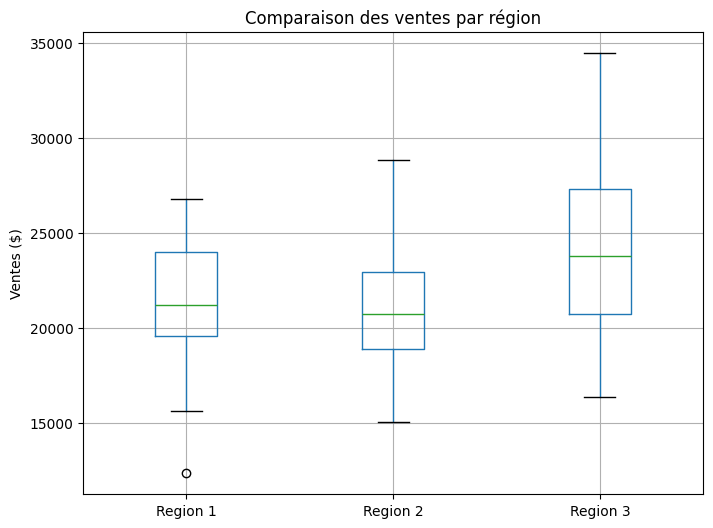

In [3]:
# ============================================================
# EXERCICE 3 : ANOVA - Comparaison de plusieurs groupes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Seed pour reproductibilité
np.random.seed(0)

# Génération des données de ventes par région
region1 = np.random.normal(20000, 3000, 30)  # Région 1 : moyenne 20000, écart-type 3000
region2 = np.random.normal(22000, 3500, 30)  # Région 2 : moyenne 22000, écart-type 3500
region3 = np.random.normal(25000, 5000, 30)  # Région 3 : moyenne 25000, écart-type 5000

sales_data = pd.DataFrame({
    'Region 1': region1,
    'Region 2': region2,
    'Region 3': region3
})

# ------------------------------------------------------------
# 1) STATISTIQUES DESCRIPTIVES
# ------------------------------------------------------------
# Avant tout test, on regarde toujours les données "à l'œil" :
# moyenne, écart-type, min/max donnent déjà une première intuition
print("=== Statistiques descriptives par région ===")
print(sales_data.describe())

# ------------------------------------------------------------
# 2) TEST ANOVA (one-way, car un seul facteur : la région)
# ------------------------------------------------------------
# f_oneway compare directement plusieurs échantillons (ici 3)
f_stat, p_value = f_oneway(
    sales_data['Region 1'],
    sales_data['Region 2'],
    sales_data['Region 3']
)

print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

# ------------------------------------------------------------
# 3) DÉCISION STATISTIQUE
# ------------------------------------------------------------
alpha = 0.05  # seuil de signification standard (5% de risque d'erreur accepté)

if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < alpha ({alpha}) -> on REJETTE H0")
    print("Conclusion : au moins une région a une moyenne de ventes significativement différente des autres.")
else:
    print(f"\np-value ({p_value:.4f}) >= alpha ({alpha}) -> on NE rejette PAS H0")
    print("Conclusion : pas de preuve statistique suffisante de différence entre les régions.")

# ------------------------------------------------------------
# 4) VISUALISATION : boxplot pour comparer visuellement les groupes
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
sales_data.boxplot()
plt.title("Comparaison des ventes par région")
plt.ylabel("Ventes ($)")
plt.show()

Slope (a)       : 2.4874
Intercept (b)   : 2.2215
R-value         : 0.9635
R-squared       : 0.9283
p-value         : 6.76e-58
Std Err (pente) : 0.0698

Équation du modèle : Test Score = 2.49 * Hours Studied + 2.22


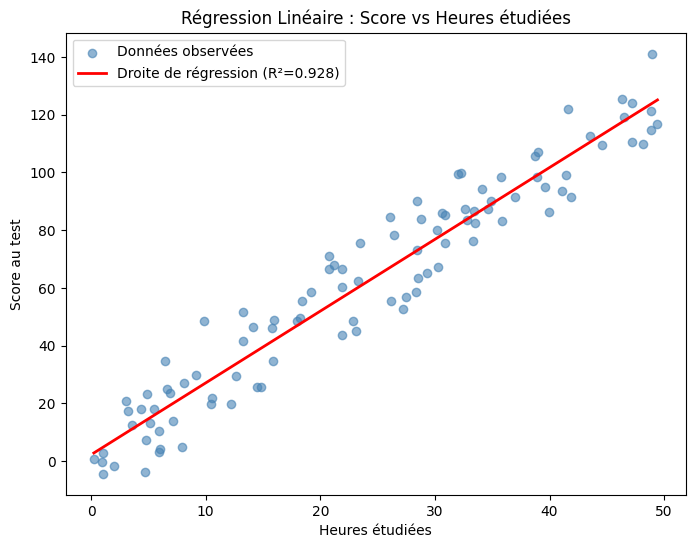

In [1]:
# ============================================================
# EXERCICE 4 : Régression Linéaire Simple
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Seed pour reproductibilité
np.random.seed(0)

# ------------------------------------------------------------
# 1) GÉNÉRATION DES DONNÉES
# ------------------------------------------------------------
X = np.random.rand(100) * 50              # Heures étudiées (variable indépendante)
Y = 2.5 * X + np.random.randn(100) * 10    # Score au test (variable dépendante)
                                             # relation vraie : Y = 2.5*X + bruit aléatoire

linear_regression_data = pd.DataFrame({
    'Hours Studied': X,
    'Test Score': Y
})

# ------------------------------------------------------------
# 2) RÉGRESSION LINÉAIRE AVEC SCIPY
# ------------------------------------------------------------
# linregress applique la méthode des moindres carrés
# et retourne directement les 5 métriques clés
slope, intercept, r_value, p_value, std_err = linregress(
    linear_regression_data['Hours Studied'],
    linear_regression_data['Test Score']
)

r_squared = r_value ** 2  # R² = part de variance de Y expliquée par X

# ------------------------------------------------------------
# 3) AFFICHAGE DES RÉSULTATS
# ------------------------------------------------------------
print(f"Slope (a)       : {slope:.4f}")
print(f"Intercept (b)   : {intercept:.4f}")
print(f"R-value         : {r_value:.4f}")
print(f"R-squared       : {r_squared:.4f}")
print(f"p-value         : {p_value:.2e}")
print(f"Std Err (pente) : {std_err:.4f}")

print(f"\nÉquation du modèle : Test Score = {slope:.2f} * Hours Studied + {intercept:.2f}")

# ------------------------------------------------------------
# 4) VISUALISATION : nuage de points + droite de régression
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, alpha=0.6, color='steelblue', label='Données observées')

# Droite de régression : on prédit Y pour une plage de X
x_line = np.linspace(X.min(), X.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Droite de régression (R²={r_squared:.3f})')

plt.xlabel("Heures étudiées")
plt.ylabel("Score au test")
plt.title("Régression Linéaire : Score vs Heures étudiées")
plt.legend()
plt.show()


### Results

| Metric | Value |
|---|---|
| Slope (a) | 2.4874 |
| Intercept (b) | 2.2215 |
| R-value | 0.9635 |
| **R-squared** | **0.9283** |
| p-value | 6.76 × 10⁻⁵⁸ |
| Std Err | 0.0698 |

### Interpretation

**Slope = 2.49** — Each additional hour studied is associated with an average
increase of approximately **2.49 points** on the test score. This is very close
to the true value (2.5) used to generate the synthetic data, showing that the
model successfully captured the underlying relationship despite the added noise.

**Intercept = 2.22** — A student who studied 0 hours would theoretically score
around 2.22 points on average. Note that this is an **extrapolation**, since
X = 0 lies at the edge of (or outside) the observed data range, so this value
has limited literal meaning in practice.

**R² = 0.928** — About **92.8% of the variance** in test scores is explained by
the number of hours studied. This is a very high R², which makes sense here
since the data was artificially generated with a strong linear relationship
plus moderate noise — in real-world social science data, an R² of 0.3–0.5 would
already be considered a good result.

**p-value ≈ 6.76 × 10⁻⁵⁸** — Extremely small, far below the 0.05 threshold.
We **reject** the null hypothesis (H₀: slope = 0, i.e., no linear relationship).
The relationship between hours studied and test score is **highly statistically
significant**.

**Std Err = 0.07** — The uncertainty around the slope estimate is small, which
reinforces confidence in the 2.49 estimate (the confidence interval around the
slope is narrow).

### Key takeaway

> Hours studied is a strong and statistically significant predictor of test
> scores in this dataset, explaining the vast majority of the variance observed.
> However, as with any regression analysis, this reflects a statistical
> **association**, not necessarily a proven **causal** effect — though in this
> specific case, the data was deliberately simulated with a causal structure
> (`Y = 2.5 * X + noise`).